<link rel="stylesheet" href="notebooks/styles.css">

<div class="title-wrap">
  <h1 class="title-main" style="font-weight: bold; font-size: 2.65rem; margin-bottom: 0.5rem;">
  Spatial Data Science Approaches to Wildfire Severity Modeling
</h1>
<h2 class="title-sub" style="font-style: italic; font-size: 1.8rem; margin-top: 0rem; margin-bottom: 0.2rem;">
  A GIS‑Driven, Tree‑Based Machine Learning Analysis of California Wildfires
</h2>
</div>

# Module 8: *Fire Ignition Modeling*
##### Version Number: 4.0
---
### Contents  
> *Build Models*\
> *Train Models*\
> *Generate Predictions*\
> *Geospatial Visualization*\
> *Export File*
---
### Notes
This section applies the trained models to predict wildfire severity in case studies with unseen data.

It evaluates and compare the performance of three classification models:
- **XGBoost**
- **Random Forest**
- **LightGBM**
---
### Inputs
- `X_ignition`,`y_ignition` ,`details_ignition` - Model testing dataset in full or reduced versions 
- `pal_X`,`pal_y`, `pal_details` Case study data for 2025 predictions
- `ignition_best_strategy` best class balancing strategies calculated from module 06
- `ignition_model_parameters` optimum model parameters as determined by module 07

---
### Outputs  
- `predictions_ignition.csv` Case study dataset containing prediction results of all three types (ignition, spread, damage) and all models. This also contain any relevant details to be used for interpolation in ArcGIS. 
- **Date range** 01/01/2025 to 01/23/2025.
---
### User Created Dependencies  

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_utils import *
from src.model_utils import *
from src.plot_utils import *

---
### Third Party Dependencies

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import json

# Modeling libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Geospatial libraries
import geopandas as gpd
from shapely.geometry import Point

---
### Global Constants

---

### Load Data

In [3]:
X_ignition = pd.read_csv('../data/processed/X_ignition.csv')
y_ignition = pd.read_csv('../data/processed/y_ignition.csv').squeeze()  # Load as Series     
details_ignition = pd.read_csv('../data/processed/details_ignition.csv')

pal_details = pd.read_csv('../data/processed/pal_details.csv')
pal_X = pd.read_csv('../data/processed/pal_X.csv')
pal_y = pd.read_csv('../data/processed/pal_y.csv')

best_strategy = pd.read_csv('../data/processed/ignition_best_strategy.csv')

with open('model_parameters_ignition.json', 'r') as f:
    model_parameters = json.load(f)

In [4]:
pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date
details_ignition['Date'] = pd.to_datetime(details_ignition['Date']).dt.date

## Model Parameters

In [5]:
RF_parameters = model_parameters['Random Forest']
XGB_parameters = model_parameters['XGBoost']

# Build tuned models
ignition_xgb = xgb.XGBClassifier(**XGB_parameters)
ignition_rf = RandomForestClassifier(**RF_parameters)

display(RF_parameters)
display(XGB_parameters)

{'n_estimators': 150,
 'max_depth': 15,
 'min_samples_split': 10,
 'max_features': 'log2',
 'class_weight': 'balanced'}

{'objective': 'multi:softmax',
 'num_class': 3,
 'n_estimators': 150,
 'max_depth': 3,
 'learning_rate': 0.4,
 'verbosity': 0}

## Train Models

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_ignition, y_ignition, test_size=0.2, random_state=14)

In [7]:
X_train_rf, y_train_rf = apply_balancing('RF', best_strategy, X_train, y_train)
X_train_xgb, y_train_xgb = apply_balancing('XGB', best_strategy, X_train, y_train)

ignition_rf.fit(X_train_rf, y_train_rf)
ignition_xgb.fit(X_train_xgb, y_train_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.4, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None, num_class=3,
              num_parallel_tree=None, ...)

## Metrics

In [8]:
evaluate_model(ignition_xgb, X_test, y_test, "Ignition XGBoost")
evaluate_model(ignition_rf, X_test, y_test, "Ignition Random Forest")

Evaluation for Ignition XGBoost
Accuracy:  0.658
Precision: 0.615
Recall:    0.658
F1 Score:  0.616


---- Classification Report ----
              precision    recall  f1-score   support

           0       0.80      0.76      0.78      6025
           1       0.58      0.80      0.67      5816
           2       0.24      0.02      0.03      1563
           3       0.15      0.01      0.01       529
           4       0.47      0.48      0.48       596

    accuracy                           0.66     14529
   macro avg       0.45      0.41      0.40     14529
weighted avg       0.61      0.66      0.62     14529



Evaluation for Ignition Random Forest
Accuracy:  0.601
Precision: 0.623
Recall:    0.601
F1 Score:  0.610


---- Classification Report ----
              precision    recall  f1-score   support

           0       0.81      0.76      0.78      6025
           1       0.61      0.57      0.59      5816
           2       0.24      0.28      0.26      1563
           3      

In [9]:
ignition_rf_importances = pd.Series(ignition_rf.feature_importances_, index=X_ignition.columns)
ignition_xgb_importances = pd.Series(ignition_xgb.feature_importances_, index=X_ignition.columns)

ignition_rf_top10 = ignition_rf_importances.sort_values(ascending=False).head(10)
ignition_xgb_top10 = ignition_xgb_importances.sort_values(ascending=False).head(10)

rf_top10 = pd.DataFrame({
    'Random Forest': ignition_rf_top10
})

xgb_top10 = pd.DataFrame({
    'XGBoost': ignition_xgb_top10
})

display(rf_top10,xgb_top10)

,Random Forest
road_length_meters,0.027740
power_line_density_x_total_housing,0.026355
total_population,0.025665
northness_mean_x_Daily Maximum Air Temperature,0.023002
road_density,0.018869
1000-hour Dead Fuel Moisture,0.018645
median_income,0.018392
Solar Radiation 7 Day Avg,0.018388
Vapor Pressure Deficit 7 Day Avg,0.018279
population_density,0.017937


,XGBoost
total_population,0.197011
road_length_meters,0.099832
Season_Summer,0.054485
total_housing,0.046814
intermix_zone,0.035408
power_line_density_x_total_housing,0.033266
power_line_meters,0.032436
dominant_province_description_California Coastal Chaparral Forest and Shrub,0.031591
dominant_province_description_Sierran Steppe-Mixed Forest-Coniferous Forest-Alpine Meadow,0.023023
Energy Release Component,0.022388


## Generate Case Study Predictions

In [10]:
# Palisades Fire (January 2025)
pal_ignition_xgb_predictions = pd.DataFrame(ignition_xgb.predict(pal_X))
pal_ignition_xgb_predictions.value_counts()

0
0    4688
1     677
4      52
2       7
3       4
Name: count, dtype: int64

In [11]:
pal_ignition_rf_predictions = pd.DataFrame(ignition_rf.predict(pal_X))
pal_ignition_rf_predictions.value_counts()

0
0    4617
1     547
2     139
4      65
3      60
Name: count, dtype: int64

### Save Predictions for plotting

In [12]:
pal_details = pal_details.copy()

pal_details['Prediction Ignition XGB'] = pal_ignition_xgb_predictions[0].values
pal_details['Prediction Ignition RF']  = pal_ignition_rf_predictions[0].values
pal_details['Prediction Ignition Actual'] = pal_y['Target_Ignition']

#### Identify specific day for plotting

In [18]:
pal_specific_date = pd.to_datetime('2025-01-07').date()
pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date

#### Define geometries

In [19]:
pal_details['geometry'] = [Point(xy) for xy in zip(pal_details['centroid_easting'], pal_details['centroid_northing'])]
pal_gdf = gpd.GeoDataFrame(pal_details , geometry='geometry', crs="EPSG:3310")

pal_gdf = pal_gdf.to_crs('4326')

pal_gdf['Longitude'] = pal_gdf.geometry.x
pal_gdf['Latitude'] = pal_gdf.geometry.y

#### Subset data for visualization

In [20]:
pal_predictions = pal_gdf[pal_gdf['Date'] == pal_specific_date]

## Visualization of Model Predictions

This section visualizes wildfire severity predictions made by each model on specific dates during the Palisades Fire (Jan 2025).

### Ignition Risk Predictions 
- Date: 01/07/2025

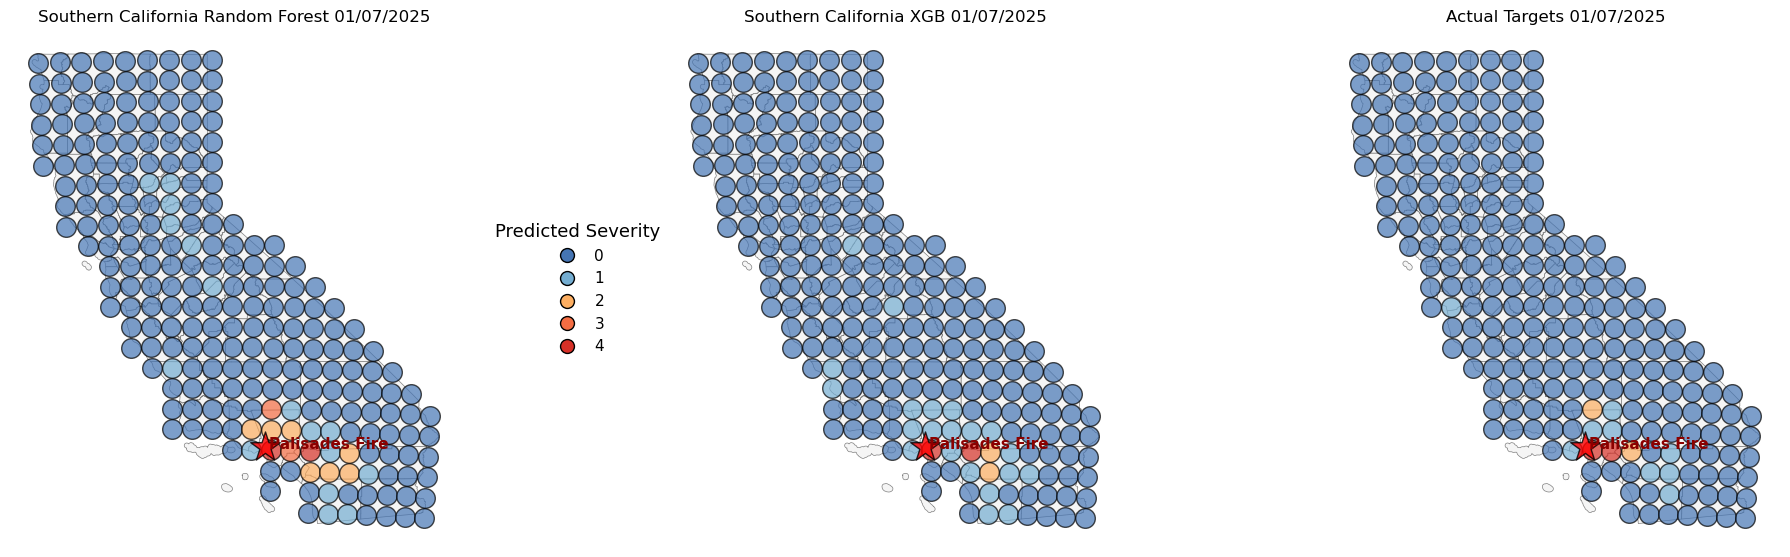

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_map(pal_predictions, 'Prediction Ignition RF', 'Palisades', ax=axes[0])
plot_map(pal_predictions, 'Prediction Ignition XGB', 'Palisades', ax=axes[1])
plot_map(pal_predictions, 'Prediction Ignition Actual', 'Palisades', ax=axes[2])

axes[0].set_title('Southern California Random Forest 01/07/2025')
axes[1].set_title('Southern California XGB 01/07/2025')
axes[2].set_title('Actual Targets 01/07/2025')

plt.tight_layout()

plt.savefig("../plots/Palisades_predictions_subset.png", dpi=600)

## Export File

In [22]:
pal_gdf.to_csv('../data/processed/predictions_ignition.csv', index=False)
print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/
